In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("data1.txt", "r") as f:
    data = [int(x) for x in f.read().split()]

data = np.array(data)

print(data)
print(len(data))


[80 74 81 90 73 73 91 83 70 80 70 70 77 56 58 69 65 78 66 61 90 73 76 61
 70 76 63 79 69 72 69 94 75 64 83 63 77 55 62 77 82 77 74 72 60 68 70 86
 78 57 78 71 68 81 85 84 67 72 78 85 70 73 64 63 83 89 74 85 79 69 79 90
 75 91 50 83 76 72 76 55 73 79 90 70 67 70 84 78 70 80 76 85 68 72 71 60
 78 78 75 73]
100


In [3]:
num_classes = 8

minimum = data.min()
maximum  = data.max()
print("minimum:" , minimum)
print("maximum:" , maximum)

data_range = maximum - minimum
print("Data Range:", data_range)
class_width = math.ceil(data_range / num_classes)
print("Class Width:", class_width)

minimum: 50
maximum: 94
Data Range: 44
Class Width: 6


##  Class Limits

In [4]:
classes = []

lower_limit = int(minimum)   

for i in range(num_classes):
    upper_limit = int(lower_limit + class_width - 1)
    classes.append((lower_limit, upper_limit))
    lower_limit = upper_limit + 1

classes


[(50, 55),
 (56, 61),
 (62, 67),
 (68, 73),
 (74, 79),
 (80, 85),
 (86, 91),
 (92, 97)]

## Class Frequency

In [5]:
freq = []
for lower, upper in classes:
    count = sum(1 for i in data if lower <= i <= upper) 
    freq.append(count)
    print(freq)


[3]
[3, 7]
[3, 7, 10]
[3, 7, 10, 29]
[3, 7, 10, 29, 26]
[3, 7, 10, 29, 26, 16]
[3, 7, 10, 29, 26, 16, 8]
[3, 7, 10, 29, 26, 16, 8, 1]


## class relative frequency %


In [6]:
relative_freq_percent = [round((f / len(data)) * 100, 2) for f in freq]

print("Class Relative Frequency (%):")
print(relative_freq_percent)

Class Relative Frequency (%):
[3.0, 7.0, 10.0, 29.0, 26.0, 16.0, 8.0, 1.0]


##  accumulated frequency and accumulated relative frequency

In [7]:
cum_freq = np.cumsum(freq)

cum_relative = np.cumsum(relative_freq_percent)

print("Cumulative Frequency:", cum_freq)
print("Cumulative Relative Frequency (%):", np.round(cum_relative, 2))

Cumulative Frequency: [  3  10  20  49  75  91  99 100]
Cumulative Relative Frequency (%): [  3.  10.  20.  49.  75.  91.  99. 100.]


## class boundaries

In [8]:
boundaries = [(low - 0.5, high + 0.5) for low, high in classes]

print("Class Boundaries:")
for b in boundaries:
    print(b)


# b = [(low - 0.5, high + 0.5) for low, high in classes]
# print("Class Boundaries:")
# print(b)

Class Boundaries:
(49.5, 55.5)
(55.5, 61.5)
(61.5, 67.5)
(67.5, 73.5)
(73.5, 79.5)
(79.5, 85.5)
(85.5, 91.5)
(91.5, 97.5)


## Histogram


In [9]:
b = classes
boints = [x[0] for x in boundaries] + [boundaries[-1][1]]

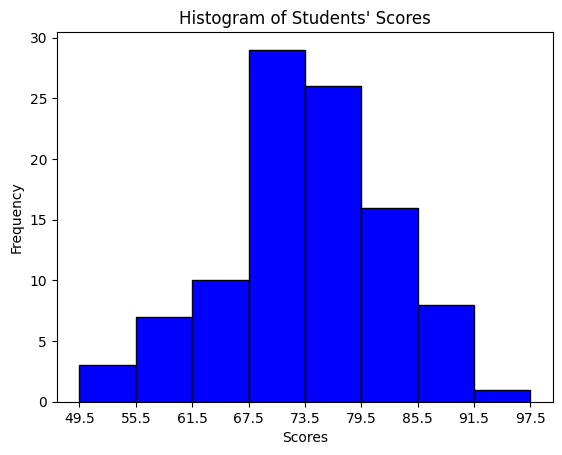

In [10]:
plt.hist(data, bins=boints, edgecolor="black", color="blue")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.title("Histogram of Students' Scores")
plt.xticks(boints)
plt.show()

## Ogive

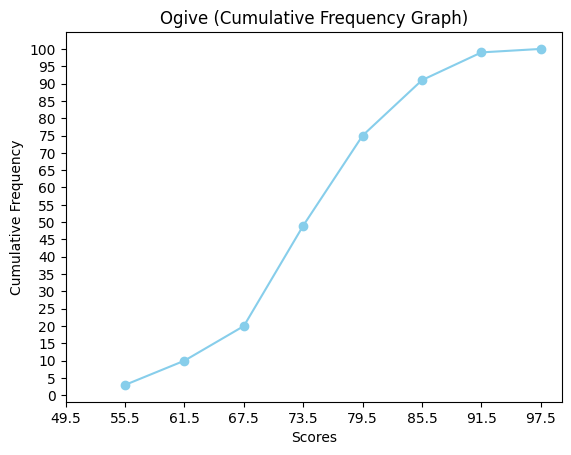

In [11]:
x = [b[1] for b in boundaries]  
y = cum_freq              
plt.plot(x, y, marker='o', color="skyblue", linestyle='-')  
plt.xlabel("Scores")
plt.ylabel("Cumulative Frequency")
plt.title("Ogive (Cumulative Frequency Graph)")
plt.xticks(boints)
plt.yticks(range(0, len(data)+1, 5))
plt.show()

## Polygon

In [12]:
midpoints = [(m + n) / 2 for m, n in classes] 


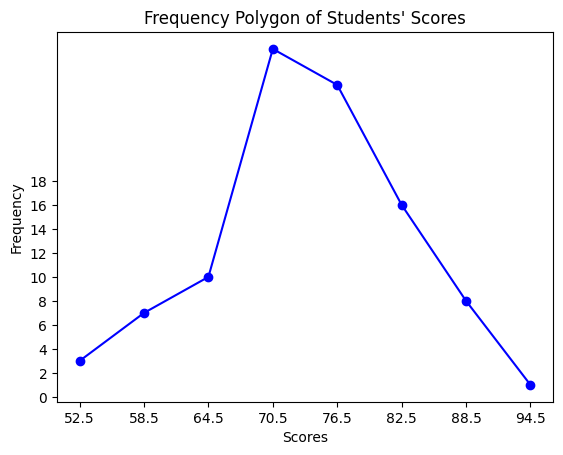

In [13]:
plt.plot(midpoints, freq, marker='o', color="blue") 
plt.xlabel("Scores")      
plt.ylabel("Frequency")     
plt.title("Frequency Polygon of Students' Scores")  
plt.xticks(midpoints)      
plt.yticks(range(0, 20, 2))
plt.show()


## Print Grouped Frequency Distribution

In [14]:
df = pd.DataFrame({
    "Class Limits": classes,
    "Class Boundaries": boundaries,
    "Midpoint": midpoints,
    "Frequency": freq,
    "Relative Freq (%)": relative_freq_percent, 
    "Cumulative Freq": cum_freq,
    "Cumulative Relative Freq (%)": np.round(cum_relative, 2)
})

print("Grouped Frequency Distribution:")
print(df)

Grouped Frequency Distribution:
  Class Limits Class Boundaries  Midpoint  Frequency  Relative Freq (%)  \
0     (50, 55)     (49.5, 55.5)      52.5          3                3.0   
1     (56, 61)     (55.5, 61.5)      58.5          7                7.0   
2     (62, 67)     (61.5, 67.5)      64.5         10               10.0   
3     (68, 73)     (67.5, 73.5)      70.5         29               29.0   
4     (74, 79)     (73.5, 79.5)      76.5         26               26.0   
5     (80, 85)     (79.5, 85.5)      82.5         16               16.0   
6     (86, 91)     (85.5, 91.5)      88.5          8                8.0   
7     (92, 97)     (91.5, 97.5)      94.5          1                1.0   

   Cumulative Freq  Cumulative Relative Freq (%)  
0                3                           3.0  
1               10                          10.0  
2               20                          20.0  
3               49                          49.0  
4               75                   

## Raw Data Statistics


In [15]:
mean_raw = np.mean(data)
std_raw = np.std(data, ddof=1)
cv_raw = (std_raw / mean_raw) * 100

print("Raw Data Statistics:")
print("Mean:", mean_raw)
print("Standard Deviation:", std_raw)
print("Coefficient of Variation (%):", cv_raw)


Raw Data Statistics:
Mean: 73.99
Standard Deviation: 9.080442965210697
Coefficient of Variation (%): 12.272527321544395


## Grouped Data Statistics


In [16]:
freq_arr = np.array(freq)
midpoints_arr = np.array(midpoints)

In [17]:
mean_grouped = np.sum(freq_arr * midpoints_arr) / np.sum(freq_arr)

variance_grouped = np.sum(freq_arr * (midpoints_arr - mean_grouped)**2) / (np.sum(freq_arr) - 1)
std_grouped = np.sqrt(variance_grouped)
cv_grouped = (std_grouped / mean_grouped) * 100

print("\nGrouped Data Statistics:")
print("Mean:", mean_grouped)
print("Standard Deviation:", std_grouped)
print("Coefficient of Variation (%):", cv_grouped)



Grouped Data Statistics:
Mean: 73.68
Standard Deviation: 8.840197447404154
Coefficient of Variation (%): 11.998096426987178
